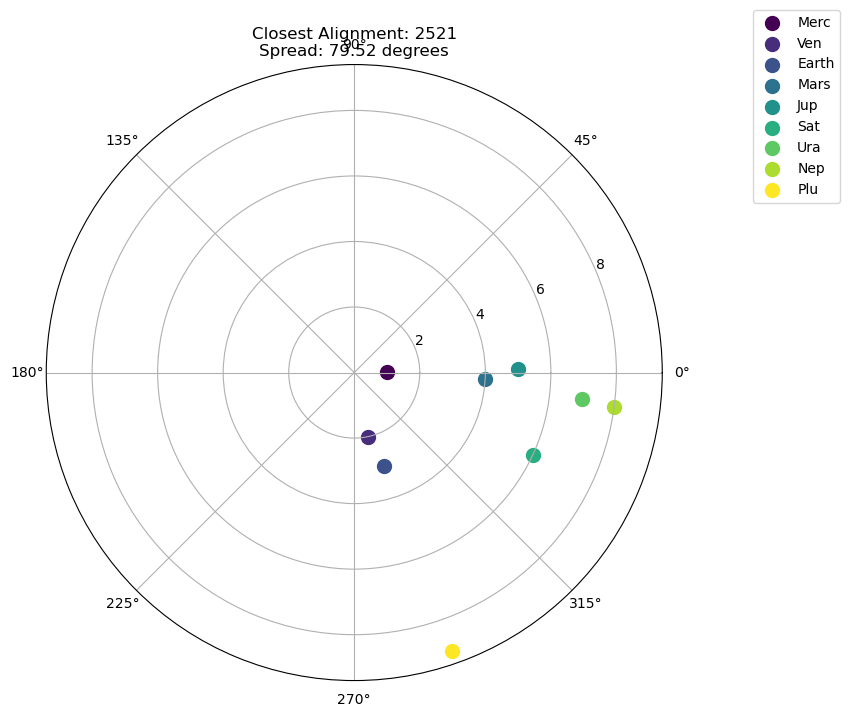

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def simulate_alignment():
    # Orbital periods in years (Mercury to Pluto)
    periods = np.array([0.24, 0.62, 1.00, 1.88, 11.86, 29.46, 84.01, 164.79, 248.00])
    names = ["Merc", "Ven", "Earth", "Mars", "Jup", "Sat", "Ura", "Nep", "Plu"]
    
    # Angular velocity (degrees per day)
    velocities = 360 / (periods * 365.25)
    
    # Starting positions (approximate for early 2026)
    # 0 degrees is the Vernal Equinox
    positions = np.array([120, 200, 100, 150, 80, 40, 30, 350, 290])
    
    # Simulate 500 years into the future
    days = 500 * 365
    best_spread = 360
    best_day = 0
    
    for day in range(days):
        current_pos = (positions + velocities * day) % 360
        # Calculate the "spread" (arc length covering all planets)
        current_pos.sort()
        # Check the gap between max and min, but also across the 0/360 boundary
        gaps = np.diff(current_pos)
        max_gap = max(gaps)
        spread = 360 - max_gap
        
        if spread < best_spread:
            best_spread = spread
            best_day = day
            if best_spread < 40: # Stop if we find a "good enough" alignment
                break

    return best_day, best_spread, (positions + velocities * best_day) % 360, names

day, spread, final_pos, names = simulate_alignment()
alignment_date = datetime(2026, 1, 8) + timedelta(days=int(day))

# --- Visualization ---
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='polar')

# Draw the planets
colors = plt.cm.viridis(np.linspace(0, 1, 9))
for i in range(9):
    ax.scatter(np.radians(final_pos[i]), i+1, label=names[i], color=colors[i], s=100)

plt.title(f"Closest Alignment: {alignment_date.year}\nSpread: {spread:.2f} degrees")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()